# 06 — EDA TP1: Riesgo de incendios en la Patagonia

Análisis exploratorio del dataset de hexágonos H3 (`patagonia_ia_con_nulos.csv`,
2542 filas) generado por el pipeline `01`–`05`. Este notebook **no** modifica esos
scripts: sólo consume el CSV y las utilidades de `src/`.

Objetivo del TP: caracterizar las variables ambientales de cada hexágono para
predecir la actividad de incendios (`n_focos`) y la clase de **riesgo alto**
(`n_focos > 150`).

In [1]:
import sys
from pathlib import Path

# Permite importar `src` corriendo el notebook desde notebooks/ o desde la raíz.
RAIZ = Path.cwd()
if (RAIZ / "src").exists():
    proj = RAIZ
else:
    proj = RAIZ.parent
sys.path.insert(0, str(proj))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.data import (
    cargar_dataset, filtrar_flaring, preparar_features,
    FEATURES_NUM, FEATURE_CAT, FEATURES, TARGET_CONT, UMBRAL_RIESGO,
)
from src import viz

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
RUTA_CSV = proj / "data" / "processed" / "patagonia_ia_con_nulos.csv"
print("Proyecto:", proj)
print("CSV     :", RUTA_CSV)

Proyecto: C:\Users\juanc\OneDrive\Desktop\PatagonIA\PatagonIA
CSV     : C:\Users\juanc\OneDrive\Desktop\PatagonIA\PatagonIA\data\processed\patagonia_ia_con_nulos.csv


## 1. Carga y filtro de flaring

Cargamos el dataset completo y aplicamos `filtrar_flaring`, que excluye el
cuadrante de Vaca Muerta (`lat > -39.5 & lon > -70`): 561 hexágonos cuya
actividad térmica corresponde a antorchas de gas, no a incendios. Esperamos
**1981 filas** tras el filtro.

In [2]:
df_full = cargar_dataset(str(RUTA_CSV))
print("Dataset completo:", df_full.shape)

df = filtrar_flaring(df_full)
print("Tras filtro flaring:", df.shape)

n_excluidos = len(df_full) - len(df)
assert len(df) == 1981, f"Esperaba 1981 filas, obtuve {len(df)}"
print(f"Hexágonos excluidos (flaring): {n_excluidos}")

# Guardamos el dataset limpio de trabajo.
RUTA_LIMPIO = proj / "data" / "processed" / "patagonia_ia.csv"
df.to_csv(RUTA_LIMPIO, index=False, encoding="utf-8")
print("Guardado:", RUTA_LIMPIO)
df.head()

Dataset completo: (2542, 22)
Tras filtro flaring: (1981, 22)
Hexágonos excluidos (flaring): 561
Guardado: C:\Users\juanc\OneDrive\Desktop\PatagonIA\PatagonIA\data\processed\patagonia_ia.csv


,hex,lat,lon,n_focos,brillo_medio,brillo_max,frp_medio,frp_max,brillo_t31_medio,pct_noche,...,n_anios_activo,mes_pico,elevacion,temp_media,precip_anual,viento_medio,humedad_relativa,cobertura_veg,dist_asentamiento_km,dist_ruta_km
0,85c30527fffffff,-42.645,-63.855,1.000,328.890,328.890,0.340,0.340,276.040,0.000,...,1.000,3.000,-16.000,13.150,335.800,7.040,72.880,pastizal,35.870,97.741
1,85c30537fffffff,-42.735,-63.973,3.000,353.680,367.000,6.947,7.590,301.733,0.000,...,1.000,1.000,74.000,13.150,335.800,7.040,72.880,pastizal,31.176,87.434
2,85c305b3fffffff,-43.009,-64.330,1.000,352.500,352.500,9.910,9.910,301.190,0.000,...,1.000,1.000,0.000,13.380,266.450,6.710,67.690,agua,48.817,65.170
3,85c30803fffffff,-40.931,-62.580,24.000,347.232,367.000,16.812,44.900,309.072,0.000,...,5.000,12.000,20.000,14.210,452.600,6.470,69.870,pastizal,36.321,34.181
4,85c30807fffffff,-40.796,-62.629,9.000,344.099,367.000,13.721,42.590,294.364,0.000,...,4.000,12.000,17.000,14.210,452.600,6.470,69.870,pastizal,28.667,22.280


## 2. Diccionario de variables

Cada fila es un hexágono H3 (resolución 5, ~8–9 km de lado). El target de
regresión es `n_focos`; el de clasificación es `riesgo_alto = n_focos > 150`.

| Variable | Tipo | Unidad | Fuente | Rango (post-filtro) |
|---|---|---|---|---|
| `hex` | id (str) | — | H3 res 5 | — |
| `lat`, `lon` | float | grados | centroide H3 | -53.9…-37.9 / -74.1…-62 |
| `n_focos` | int | conteo | NASA FIRMS VIIRS | 1 … 2908 |
| `brillo_medio` / `brillo_max` | float | K | FIRMS (banda I4) | — |
| `frp_medio` / `frp_max` | float | MW | FIRMS (Fire Radiative Power) | — |
| `brillo_t31_medio` | float | K | FIRMS (banda I5) | — |
| `pct_noche` | float | proporción | FIRMS (daynight) | 0 … 1 |
| `pct_verano` | float | proporción | FIRMS (mes DEF) | 0 … 1 |
| `pct_conf_alta` | float | proporción | FIRMS (confidence=h) | 0 … 1 |
| `n_anios_activo` | int | años | FIRMS | 1 … 12 |
| `mes_pico` | int | mes (1–12) | FIRMS | 1 … 12 |
| **`elevacion`** | float | m | OpenTopoData (SRTM30m) | -70 … 2092 |
| **`temp_media`** | float | °C | NASA POWER (T2M) | -1.2 … 15.6 |
| **`precip_anual`** | float | mm/año | NASA POWER (PRECTOTCORR) | 186 … 1730 |
| **`viento_medio`** | float | m/s | NASA POWER (WS10M) | 1.8 … 8.7 |
| **`humedad_relativa`** | float | % | NASA POWER (RH2M) | 48.7 … 91.1 |
| **`cobertura_veg`** | categórica | clase | ESA WorldCover 2021 | 8 clases |
| **`dist_asentamiento_km`** | float | km | IGN (asentamientos) | 1.2 … 228.6 |
| **`dist_ruta_km`** | float | km | IGN (vial nacional) | 0.02 … 259.2 |

En **negrita**, las 8 predictoras del TP1 (`preparar_features`).

In [3]:
X, y_cont, y_bin = preparar_features(df)
print("X:", X.shape, "| predictoras:", list(X.columns))
print("y_cont (n_focos):", y_cont.shape)
print("y_bin  (riesgo_alto):", y_bin.shape)
X.dtypes

X: (1981, 8) | predictoras: ['elevacion', 'temp_media', 'precip_anual', 'viento_medio', 'humedad_relativa', 'dist_asentamiento_km', 'dist_ruta_km', 'cobertura_veg']
y_cont (n_focos): (1981,)
y_bin  (riesgo_alto): (1981,)


elevacion               float64
temp_media              float64
precip_anual            float64
viento_medio            float64
humedad_relativa        float64
dist_asentamiento_km    float64
dist_ruta_km            float64
cobertura_veg            object
dtype: object

## 3. Análisis univariado

`describe()` de las 8 predictoras + `n_focos`, seguido de histograma y boxplot
de cada variable numérica.

In [4]:
cols_univ = FEATURES_NUM + [TARGET_CONT]
df[cols_univ].describe().T

,count,mean,std,min,25%,50%,75%,max
elevacion,"1,980.000",502.130,448.434,-70.000,115.750,377.000,809.000,"2,092.000"
temp_media,"1,981.000",9.255,3.759,-1.180,6.020,8.810,11.830,15.640
precip_anual,"1,981.000",606.416,372.753,186.150,281.050,467.200,938.050,"1,730.100"
viento_medio,"1,981.000",5.086,1.649,1.820,3.770,5.260,6.430,8.660
humedad_relativa,"1,981.000",70.066,12.060,48.730,60.250,70.350,81.470,91.120
dist_asentamiento_km,"1,981.000",63.814,46.851,1.159,28.449,50.854,89.529,228.619
dist_ruta_km,"1,981.000",54.373,50.825,0.022,14.523,37.830,79.498,259.241
n_focos,"1,981.000",85.574,242.535,1.000,2.000,8.000,49.000,"2,908.000"


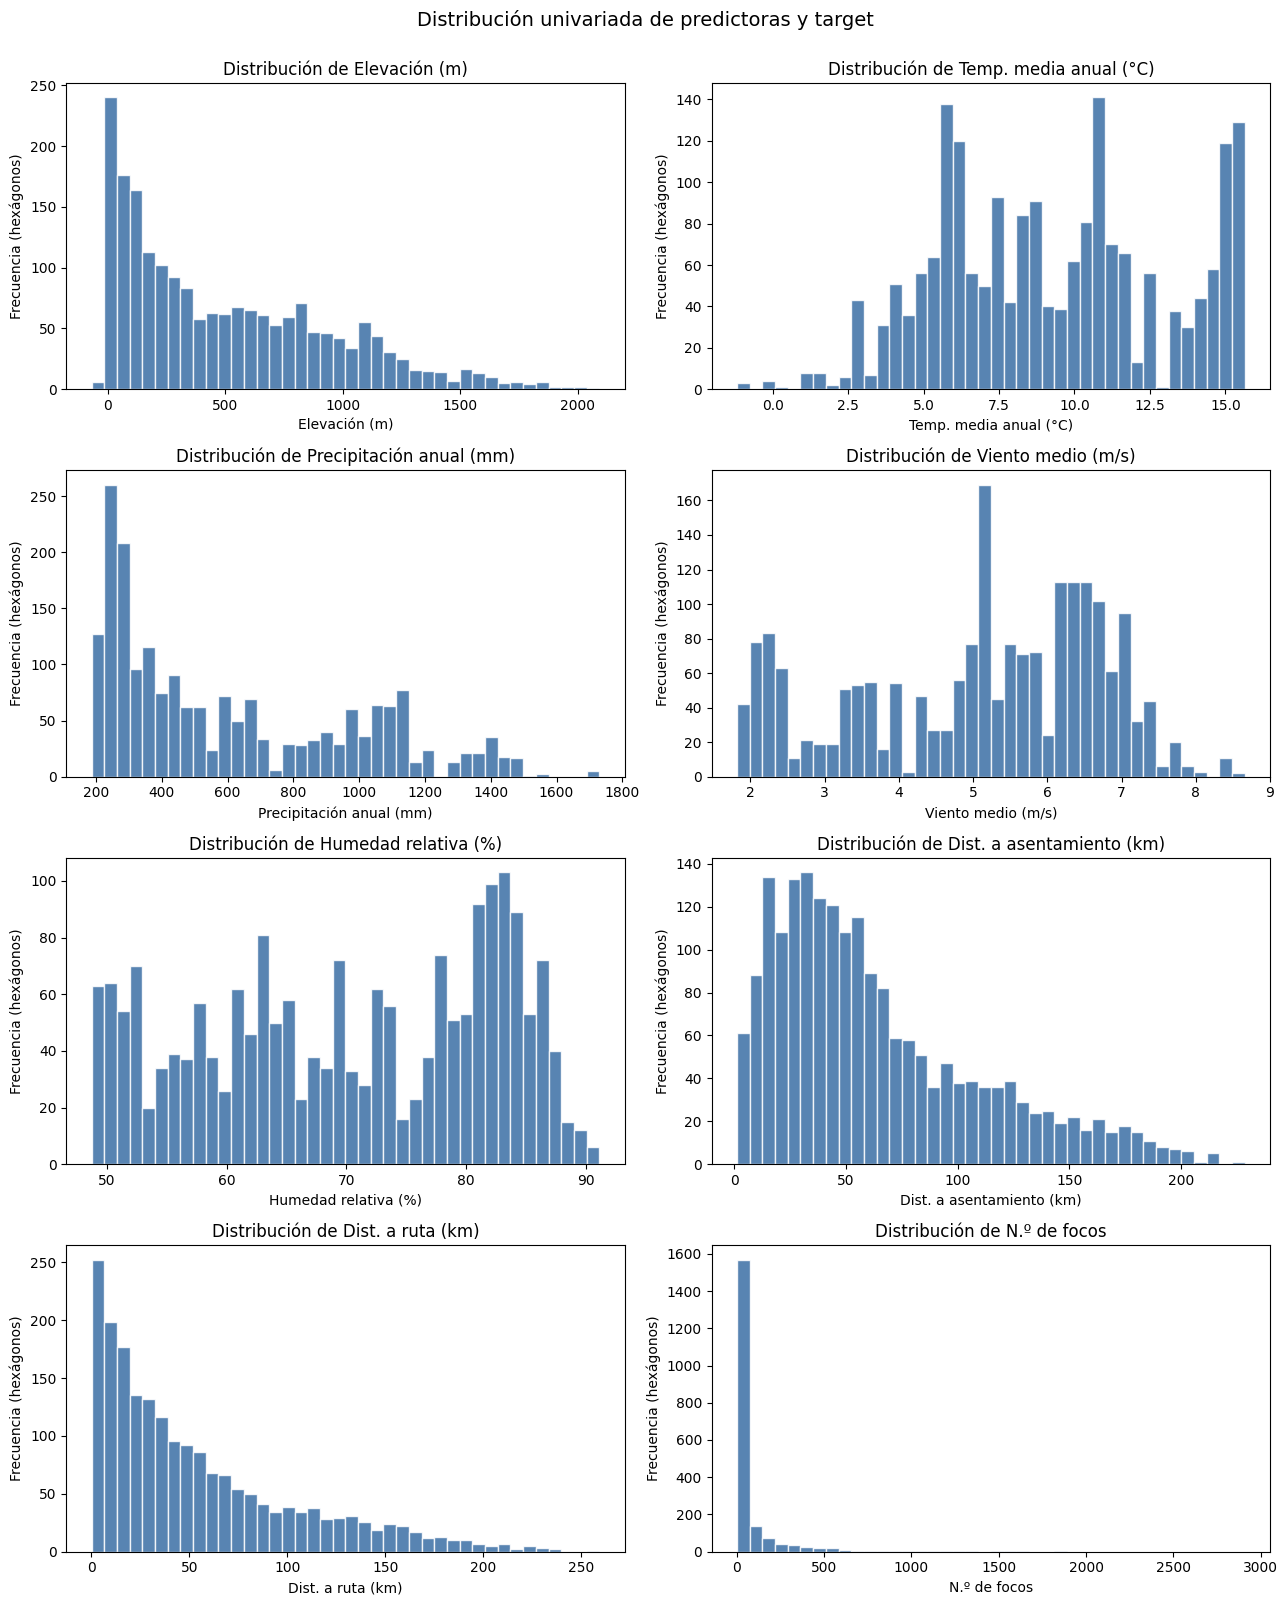

In [5]:
# Histogramas de las 7 predictoras numéricas + n_focos
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.ravel(), cols_univ):
    viz.plot_distribucion(df, col, ax=ax)
fig.suptitle("Distribución univariada de predictoras y target", y=1.0, fontsize=14)
fig.tight_layout()
plt.show()

**Lectura de los histogramas.** Las variables climáticas de NASA POWER
(`temp_media`, `precip_anual`, `viento_medio`, `humedad_relativa`) muestran
distribuciones acotadas y multimodales: reflejan gradientes geográficos
(cordillera húmeda al oeste vs. estepa seca al este) más que ruido. `elevacion`
está fuertemente sesgada a valores bajos (predominio de estepa). Las dos
distancias IGN tienen cola derecha larga (hexágonos remotos). `n_focos` es la
más extrema: casi todo el peso en valores bajos con una cola larguísima.

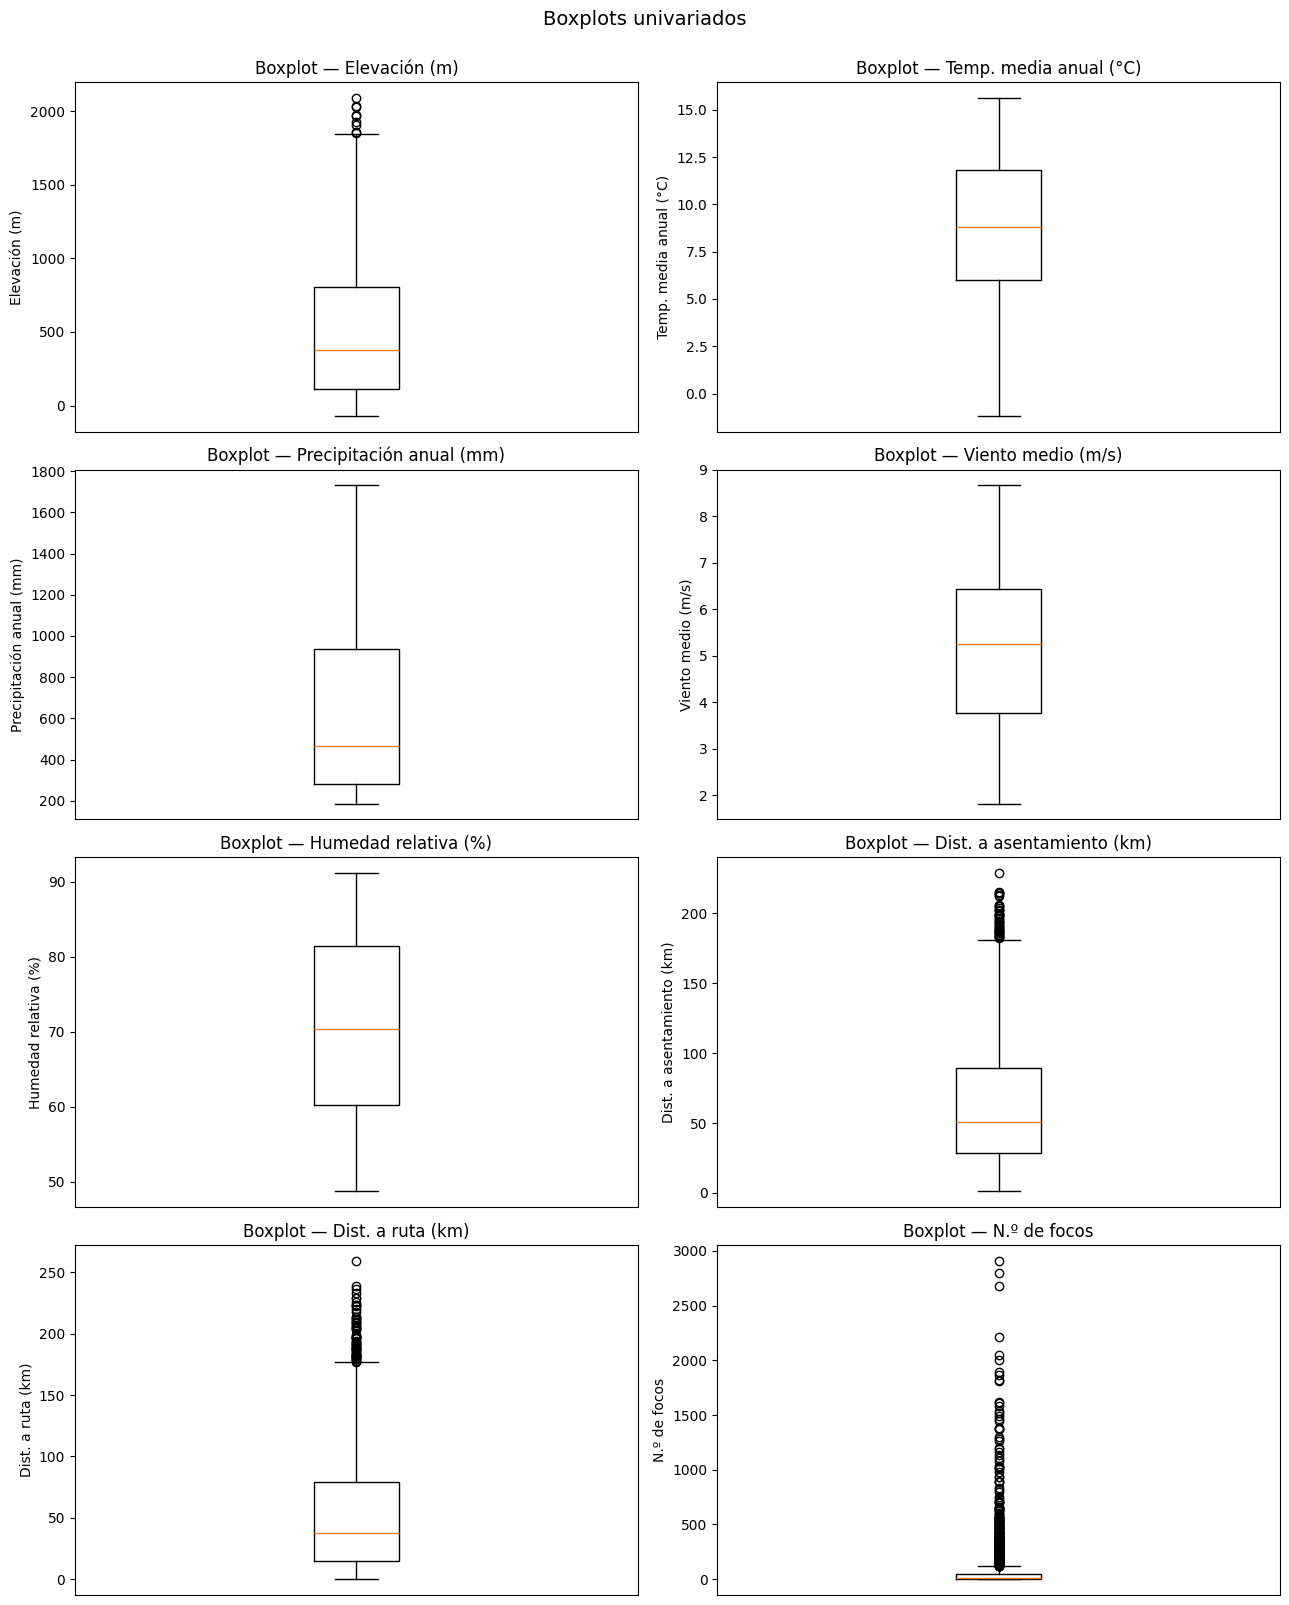

In [6]:
# Boxplots (escala compartida no aplica: cada variable en su rango)
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.ravel(), cols_univ):
    ax.boxplot(df[col].dropna().values, vert=True, showfliers=True)
    ax.set_title(f"Boxplot — {viz._label(col)}")
    ax.set_ylabel(viz._label(col))
    ax.set_xticks([])
fig.suptitle("Boxplots univariados", y=1.0, fontsize=14)
fig.tight_layout()
plt.show()

**Lectura de los boxplots.** Confirman lo anterior: `n_focos`,
`dist_asentamiento_km` y `dist_ruta_km` presentan numerosos puntos por encima
del bigote superior (outliers por criterio IQR, ver §6). Las variables
climáticas están comparativamente bien contenidas.

## 4. Análisis bivariado

Matriz de correlación, dispersión de cada predictora numérica vs `n_focos`, y
boxplot de `n_focos` por clase de cobertura vegetal.

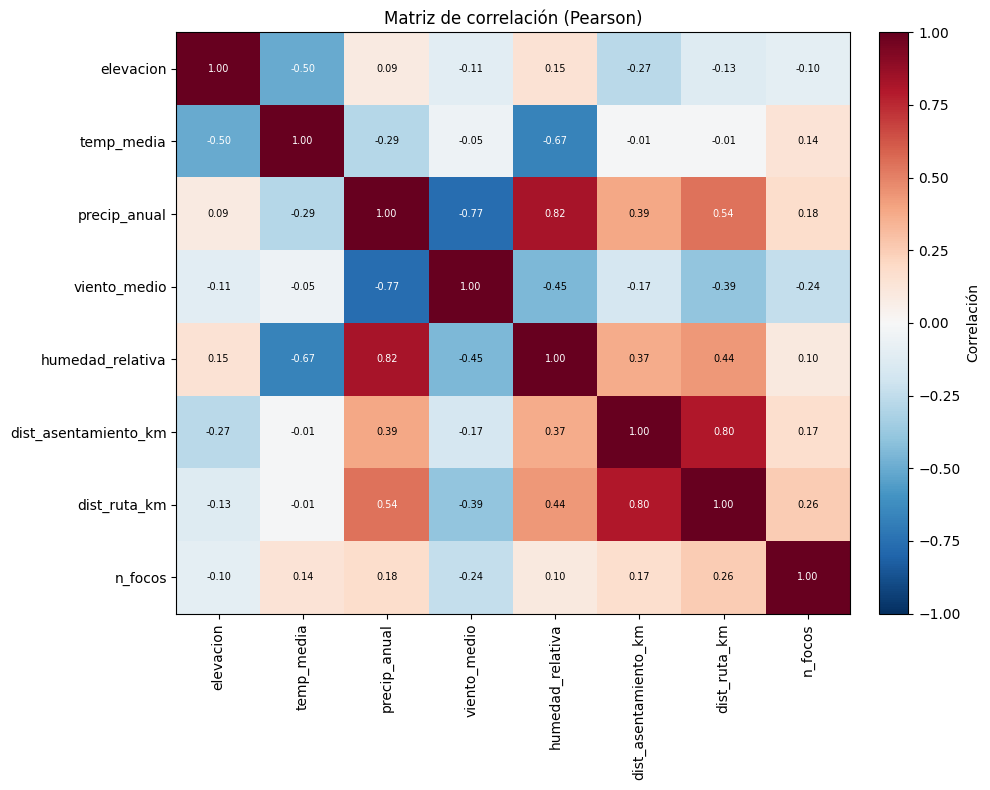

In [7]:
viz.plot_matriz_correlacion(df[cols_univ])
plt.tight_layout()
plt.show()

**Lectura de la correlación.** Las correlaciones lineales de las
predictoras con `n_focos` son débiles: la relación (si existe) no es lineal, lo
que anticipa que modelos de árbol capturarán mejor la señal que una regresión
lineal simple. Entre predictoras hay bloques esperables (clima acoplado a
elevación y a las distancias), útil para vigilar multicolinealidad.

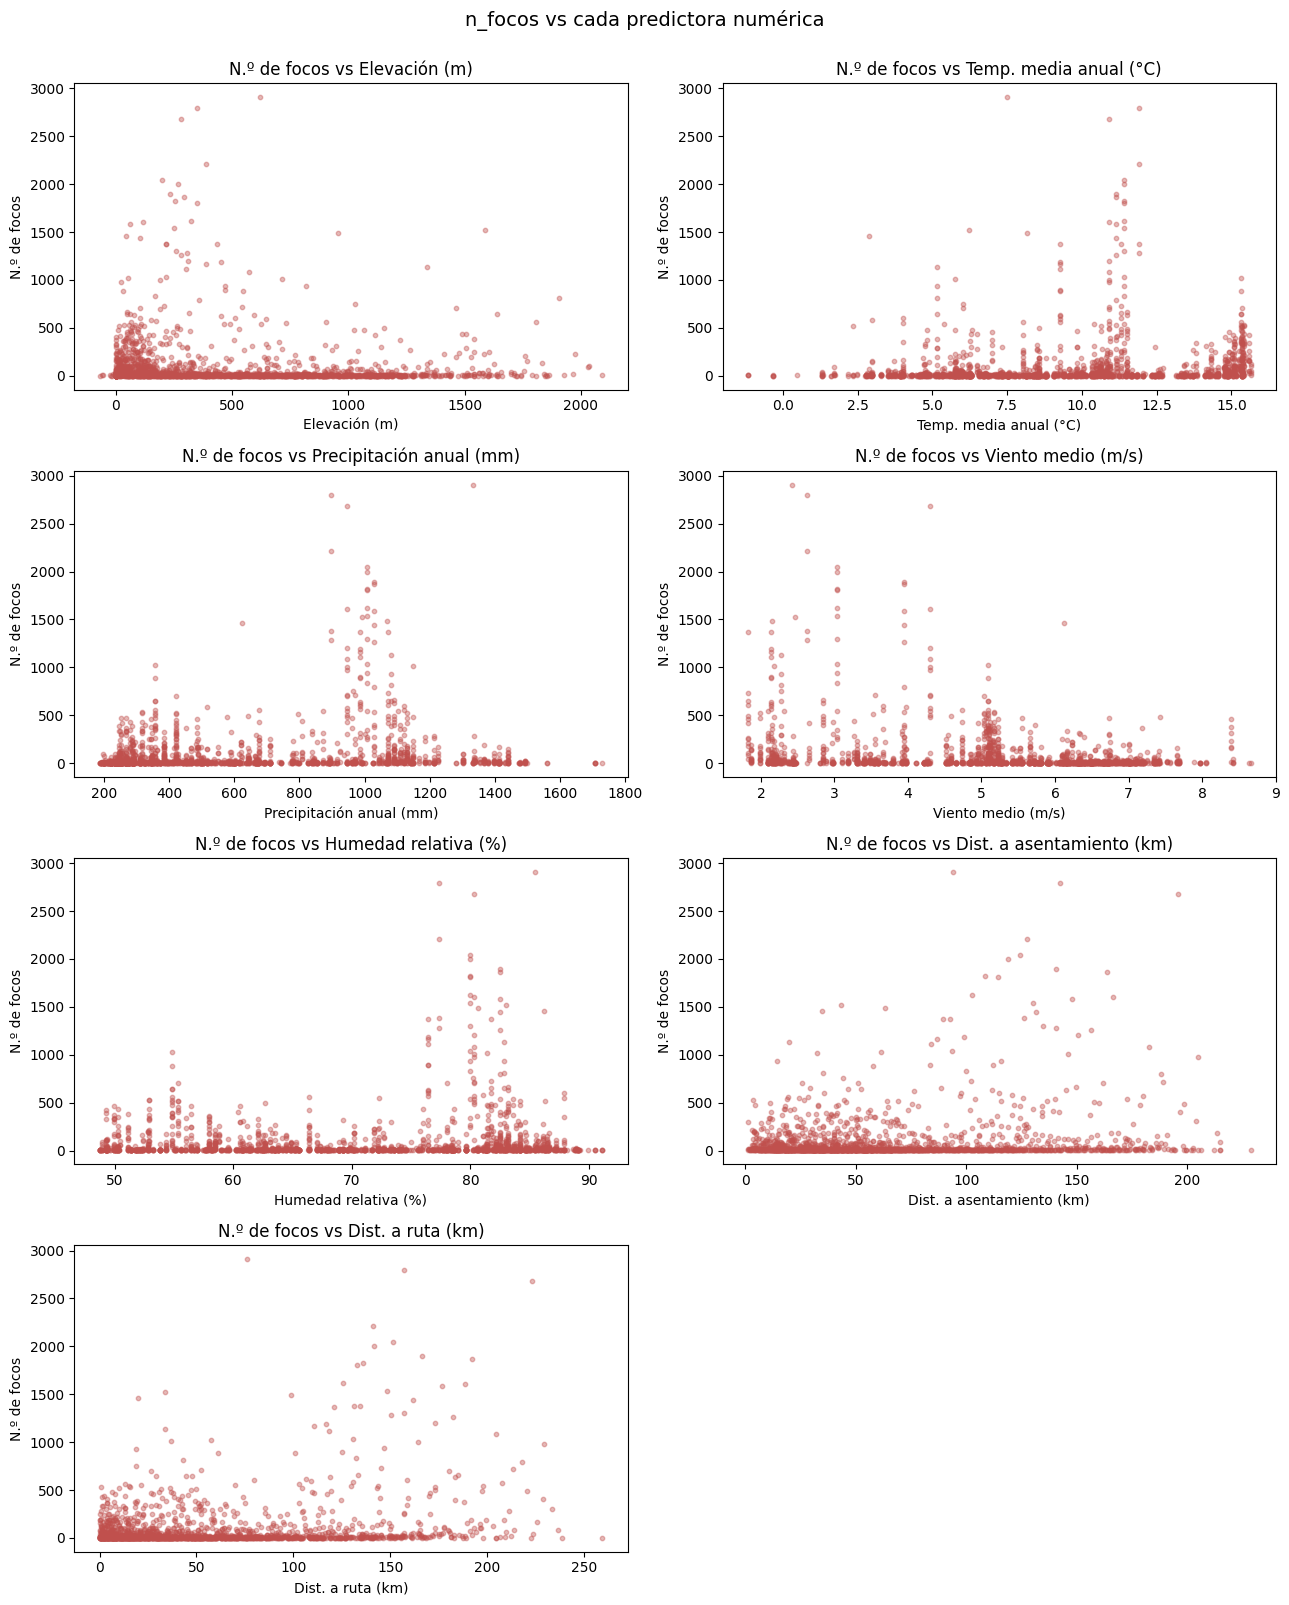

In [8]:
# Scatter de cada predictora numérica vs n_focos
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.ravel(), FEATURES_NUM):
    viz.plot_bivariado(df, col, TARGET_CONT, ax=ax)
# El 8º panel queda para el boxplot categórico
axes.ravel()[-1].axis("off")
fig.suptitle("n_focos vs cada predictora numérica", y=1.0, fontsize=14)
fig.tight_layout()
plt.show()

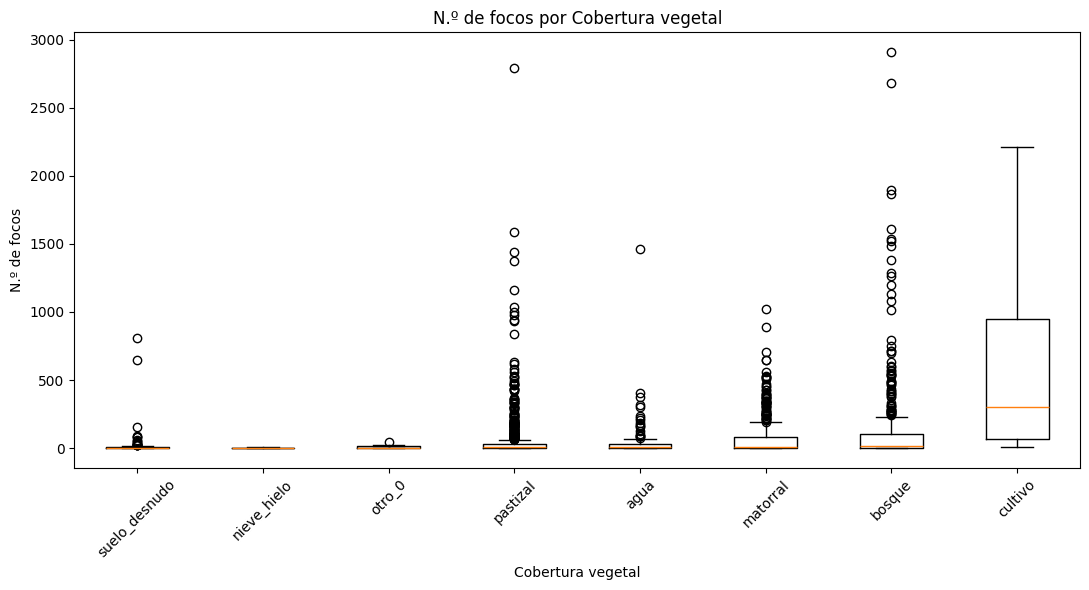

,count,median,mean,max
cobertura_veg,,,,
agua,136,8.000,44.654,"1,461.000"
bosque,377,18.000,143.202,"2,908.000"
cultivo,40,300.000,612.550,"2,213.000"
matorral,466,10.500,73.567,"1,025.000"
nieve_hielo,3,4.000,3.333,5.000
otro_0,12,4.500,9.750,44.000
pastizal,791,7.000,60.415,"2,795.000"
suelo_desnudo,156,2.000,17.712,811.000


In [9]:
# n_focos por cobertura vegetal
fig, ax = plt.subplots(figsize=(11, 6))
viz.plot_bivariado(df, FEATURE_CAT, TARGET_CONT, ax=ax)
plt.tight_layout()
plt.show()

df.groupby("cobertura_veg")["n_focos"].agg(["count", "median", "mean", "max"])

**Lectura bivariada.** En los scatter, los `n_focos` altos se concentran
en franjas específicas (elevaciones bajas-medias, precipitación intermedia,
cercanía relativa a rutas), pero con enorme dispersión. Por cobertura, las
clases con vegetación combustible (`pastizal`, `matorral`, `bosque`) muestran
mayor mediana y cola de `n_focos` que `agua`, `nieve_hielo` o `suelo_desnudo`:
la cobertura aporta señal categórica relevante.

## 5. Variable objetivo `riesgo_alto`

`riesgo_alto = (n_focos > 150)`. Conteo y proporción de clases (esperado ≈ 13.68 %).

                 conteo  porcentaje
riesgo_bajo (0)    1710      86.320
riesgo_alto (1)     271      13.680

% riesgo_alto = 13.68%  (esperado 13.68%)


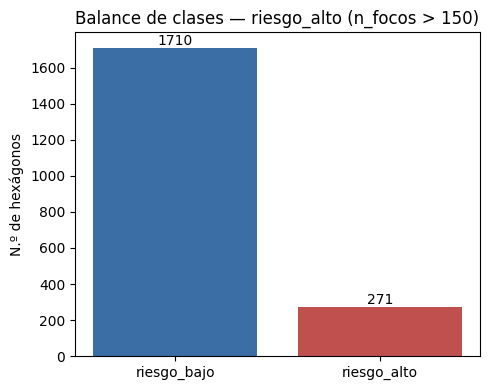

In [10]:
conteo = y_bin.value_counts().sort_index()
pct = 100 * y_bin.value_counts(normalize=True).sort_index()
resumen_target = pd.DataFrame({"conteo": conteo, "porcentaje": pct.round(2)})
resumen_target.index = ["riesgo_bajo (0)", "riesgo_alto (1)"]
print(resumen_target)
print(f"\n% riesgo_alto = {pct.loc[1]:.2f}%  (esperado 13.68%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["riesgo_bajo", "riesgo_alto"], conteo.values,
       color=["#3b6ea5", "#c0504d"])
ax.set_title("Balance de clases — riesgo_alto (n_focos > 150)")
ax.set_ylabel("N.º de hexágonos")
for i, v in enumerate(conteo.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Lectura.** Clase fuertemente desbalanceada (~1 de cada 7 hexágonos es
riesgo alto). Habrá que tenerlo en cuenta en la clasificación (métricas más allá
de accuracy, posible reponderación o resampleo).

## 6. Detección de outliers (IQR y z-score)

Se detectan, **no se tratan**. Criterios: IQR (fuera de `[Q1-1.5·IQR, Q3+1.5·IQR]`)
y z-score (`|z| > 3`).

In [11]:
def resumen_outliers(serie: pd.Series) -> dict:
    s = serie.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = int(((s < low) | (s > high)).sum())
    z = np.abs(stats.zscore(s))
    n_z = int((z > 3).sum())
    return {
        "n": len(s),
        "out_IQR": n_iqr, "%_IQR": round(100 * n_iqr / len(s), 2),
        "out_z>3": n_z, "%_z>3": round(100 * n_z / len(s), 2),
        "lim_inf_IQR": round(low, 2), "lim_sup_IQR": round(high, 2),
    }

tabla_out = pd.DataFrame(
    {c: resumen_outliers(df[c]) for c in cols_univ}
).T
tabla_out

,n,out_IQR,%_IQR,out_z>3,%_z>3,lim_inf_IQR,lim_sup_IQR
elevacion,"1,980.000",9.000,0.450,10.000,0.510,-924.120,"1,848.880"
temp_media,"1,981.000",0.000,0.000,0.000,0.000,-2.700,20.540
precip_anual,"1,981.000",0.000,0.000,1.000,0.050,-704.450,"1,923.550"
viento_medio,"1,981.000",0.000,0.000,0.000,0.000,-0.220,10.420
humedad_relativa,"1,981.000",0.000,0.000,0.000,0.000,28.420,113.300
dist_asentamiento_km,"1,981.000",42.000,2.120,9.000,0.450,-63.170,181.150
dist_ruta_km,"1,981.000",61.000,3.080,20.000,1.010,-82.940,176.960
n_focos,"1,981.000",307.000,15.500,41.000,2.070,-68.500,119.500


**Lectura.** `n_focos` y las dos distancias IGN concentran la mayor
proporción de outliers por IQR (cola derecha estructural, no errores). Como el
objetivo del modelo es justamente identificar los hexágonos de actividad
extrema, estos valores **no deben eliminarse**; la §8 explora una transformación
que comprime la cola sin descartar información.

## 7. Nulos por columna

In [12]:
na_abs = df.isna().sum()
na_pct = (100 * na_abs / len(df)).round(3)
tabla_na = pd.DataFrame({"nulos": na_abs, "%": na_pct})
tabla_na[tabla_na["nulos"] > 0] if (na_abs > 0).any() else tabla_na

,nulos,%
elevacion,1,0.050


In [13]:
# Nulos en el dataset COMPLETO (antes del filtro) para contexto del hallazgo.
na_full = df_full.isna().sum()
print("Nulos en dataset completo (2542 filas):")
print(na_full[na_full > 0] if (na_full > 0).any() else "  ninguno")
print(f"\nFilas que el dropna original (sobre 5 col. ambientales) habría eliminado: "
      f"{int(df_full[['elevacion','temp_media','precip_anual','viento_medio','humedad_relativa']].isna().any(axis=1).sum())}")

Nulos en dataset completo (2542 filas):
elevacion    1
dtype: int64

Filas que el dropna original (sobre 5 col. ambientales) habría eliminado: 1


**Hallazgo sobre los nulos.** El pipeline original (`05_join_final.py`)
aplicaba un `dropna` sobre las columnas ambientales. En la práctica ese `dropna`
eliminaba **una sola fila** de todo el dataset: el enriquecimiento vía APIs
(OpenTopoData, NASA POWER, ESA WorldCover, IGN) devolvió cobertura casi total.
El dataset llega, por tanto, **prácticamente sin nulos** (un único hexágono
austral sin elevación).

Esto es en sí mismo un dato a discutir: un EDA que no encuentra nulos que
imputar no significa que el problema de datos faltantes no exista, sino que fue
resuelto *aguas arriba* por el diseño del pipeline (cachés granulares, reintentos,
`-999 → NaN`). La ausencia de nulos es una propiedad del proceso de construcción,
no del fenómeno; conviene documentarla en lugar de darla por sentada.

## 8. Transformación de `n_focos`: original vs `log1p`

`n_focos` tiene asimetría extrema. Comparamos su distribución con `log1p(n_focos)`.

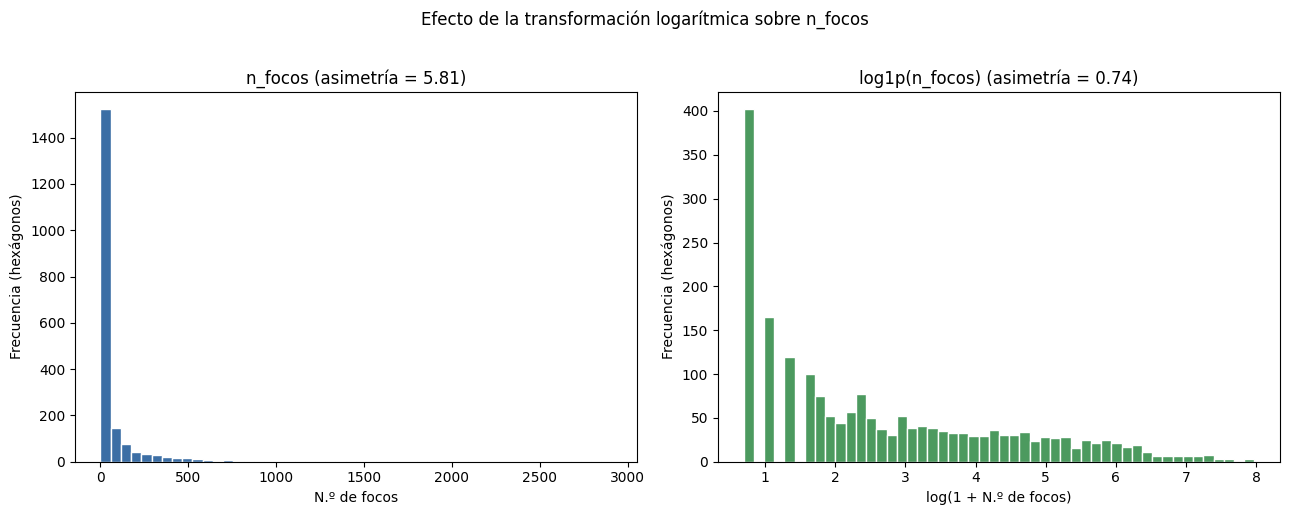

Asimetría original : 5.811
Asimetría log1p    : 0.741


In [14]:
n_focos = df["n_focos"]
log_focos = np.log1p(n_focos)

asim_orig = stats.skew(n_focos)
asim_log = stats.skew(log_focos)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(n_focos, bins=50, color="#3b6ea5", edgecolor="white")
axes[0].set_title(f"n_focos (asimetría = {asim_orig:.2f})")
axes[0].set_xlabel("N.º de focos")
axes[0].set_ylabel("Frecuencia (hexágonos)")

axes[1].hist(log_focos, bins=50, color="#4c9a5f", edgecolor="white")
axes[1].set_title(f"log1p(n_focos) (asimetría = {asim_log:.2f})")
axes[1].set_xlabel("log(1 + N.º de focos)")
axes[1].set_ylabel("Frecuencia (hexágonos)")
fig.suptitle("Efecto de la transformación logarítmica sobre n_focos", y=1.02)
fig.tight_layout()
plt.show()

print(f"Asimetría original : {asim_orig:.3f}")
print(f"Asimetría log1p    : {asim_log:.3f}")

**Lectura.** `log1p` reduce la asimetría de ~5.8 a un valor cercano a 0,
convirtiendo una distribución de cola pesada en una casi simétrica. Para
regresión con modelos sensibles a la escala del target (lineales), transformar
`n_focos` con `log1p` es recomendable; para árboles/boosting es indiferente en
el ranking pero puede estabilizar la pérdida.

## 9. Encoding de `cobertura_veg` (one-hot)

In [15]:
X_enc = pd.get_dummies(X, columns=[FEATURE_CAT], prefix=FEATURE_CAT)
print("Shape antes del encoding:", X.shape)
print("Shape tras one-hot      :", X_enc.shape)
print("Categorías codificadas  :", df[FEATURE_CAT].nunique())
print("\nNuevas columnas:")
print([c for c in X_enc.columns if c.startswith(FEATURE_CAT)])
X_enc.head()

Shape antes del encoding: (1981, 8)
Shape tras one-hot      : (1981, 15)
Categorías codificadas  : 8

Nuevas columnas:
['cobertura_veg_agua', 'cobertura_veg_bosque', 'cobertura_veg_cultivo', 'cobertura_veg_matorral', 'cobertura_veg_nieve_hielo', 'cobertura_veg_otro_0', 'cobertura_veg_pastizal', 'cobertura_veg_suelo_desnudo']


,elevacion,temp_media,precip_anual,viento_medio,humedad_relativa,dist_asentamiento_km,dist_ruta_km,cobertura_veg_agua,cobertura_veg_bosque,cobertura_veg_cultivo,cobertura_veg_matorral,cobertura_veg_nieve_hielo,cobertura_veg_otro_0,cobertura_veg_pastizal,cobertura_veg_suelo_desnudo
0,-16.000,13.150,335.800,7.040,72.880,35.870,97.741,False,False,False,False,False,False,True,False
1,74.000,13.150,335.800,7.040,72.880,31.176,87.434,False,False,False,False,False,False,True,False
2,0.000,13.380,266.450,6.710,67.690,48.817,65.170,True,False,False,False,False,False,False,False
3,20.000,14.210,452.600,6.470,69.870,36.321,34.181,False,False,False,False,False,False,True,False
4,17.000,14.210,452.600,6.470,69.870,28.667,22.280,False,False,False,False,False,False,True,False


**Lectura.** `cobertura_veg` tiene 8 clases → el one-hot añade 8 columnas
binarias (o 7 si se usara `drop_first` para evitar colinealidad en modelos
lineales). La matriz pasa de 8 a 15 columnas.

## 10. Escalado: rangos y consideraciones por tipo de modelo

In [16]:
tabla_rangos = df[FEATURES_NUM].agg(["min", "max", "mean", "std"]).T
tabla_rangos["rango"] = tabla_rangos["max"] - tabla_rangos["min"]
tabla_rangos.round(2)

,min,max,mean,std,rango
elevacion,-70.000,"2,092.000",502.130,448.430,"2,162.000"
temp_media,-1.180,15.640,9.250,3.760,16.820
precip_anual,186.150,"1,730.100",606.420,372.750,"1,543.950"
viento_medio,1.820,8.660,5.090,1.650,6.840
humedad_relativa,48.730,91.120,70.070,12.060,42.390
dist_asentamiento_km,1.160,228.620,63.810,46.850,227.460
dist_ruta_km,0.020,259.240,54.370,50.820,259.220


**Lectura sobre escalado.** Los rangos son heterogéneos: `viento_medio`
vive en `[1.8, 8.7]` mientras `precip_anual` llega a 1730 y las distancias a
~260 km. Implicaciones:

- **Modelos basados en distancia / gradiente** (k-NN, SVM, regresión
  logística/lineal regularizada, redes): son sensibles a la escala; sin
  estandarizar (`StandardScaler`) o normalizar, las variables de mayor rango
  dominan la métrica y la regularización. Aquí el escalado es **necesario**.
- **Modelos de árbol** (árbol de decisión, Random Forest, Gradient Boosting):
  parten por umbrales sobre cada variable de forma independiente de la escala;
  el escalado es **innecesario** y no cambia el resultado.

Dado que `n_focos` vs las predictoras mostró relaciones no lineales (§4), los
modelos de árbol son candidatos naturales; de usarse un modelo lineal, el
escalado y la transformación `log1p` del target pasan a ser pasos obligados.